## IMPACT DE LA MISE EN SERVICE D'UNE NOUVELLE STATION DE METRO SUR LE PRIX DE L'IMMOBILIER
### Projet 2A - Python pour la data science 
*Sonny Augusto, Abel Cornet-Carlos et Mayténa Labinsky*

## INTRODUCTION
Rennes est l'une des plus petites villes au monde à disposer d'un réseau de métro automatique. Parmi les nombreux critères qui déterminent le prix d'un bien immobilier, l'accessibilité aux transports en commun est un facteur différenciant. Dans ce contexte, ce projet analyse dans quelle mesure la mise en service d'une nouvelle ligne de métro impacte la valeur de l'immobilier des quartiers desservis. Notre objectif est de quantifier précisément la plus-value immobilière (en pourcentage) générée par la proximité immédiate d'une nouvelle station.

## Sommaire
- [Installation](#installation)
- [Préparation des Données](#préparation-des-données)
- [Statistiques Descriptives](#statistiques-descriptives)
- [Modèle de prédiction de la plus-value](#modèle-de-prédiction-du-prix)
- [Conclusion](#conclusion)

## Installation

In [1]:
!pip install -r requirements.txt
#Modules:
import geopandas as gpd
import pandas as pd
#Fonctions:
import src.clear_data as cd
import src.get_data as gd
import src.analyse_data as ad
import matplotlib.pyplot as plt
import seaborn as sns

# Préparation des données

Adresses

In [2]:
url_metro = "https://data.rennesmetropole.fr/explore/dataset/topologie-des-points-darret-de-metro-du-reseau-star/download/?format=geojson"

url_dvf2021 = "https://files.data.gouv.fr/geo-dvf/latest/csv/2021/full.csv.gz"

url_dvf2022 = "https://files.data.gouv.fr/geo-dvf/latest/csv/2022/full.csv.gz"

url_dvf2023 = "https://files.data.gouv.fr/geo-dvf/latest/csv/2023/full.csv.gz"

url_dvf2024 = "https://files.data.gouv.fr/geo-dvf/latest/csv/2024/full.csv.gz"

url_dvf2025 = "https://files.data.gouv.fr/geo-dvf/latest/csv/2025/full.csv.gz"

Import et modifications

In [3]:
#Import
df_dvf_raw2021 = gd.fetch_dvf_api(url_dvf2021)
df_dvf_raw2022 = gd.fetch_dvf_api(url_dvf2022)
df_dvf_raw2023 = gd.fetch_dvf_api(url_dvf2023)
df_dvf_raw2024 = gd.fetch_dvf_api(url_dvf2024)
df_dvf_raw2025 = gd.fetch_dvf_api(url_dvf2025)


--- Récupération DVF (Source miroir stable) ---
--- Récupération DVF (Source miroir stable) ---


/home/onyxia/work/Projet-python-pour-la-data-science/src/get_data.py:46: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_rennes = pd.concat(df_rennes_list)


--- Récupération DVF (Source miroir stable) ---


/home/onyxia/work/Projet-python-pour-la-data-science/src/get_data.py:46: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_rennes = pd.concat(df_rennes_list)


--- Récupération DVF (Source miroir stable) ---


/home/onyxia/work/Projet-python-pour-la-data-science/src/get_data.py:46: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_rennes = pd.concat(df_rennes_list)


--- Récupération DVF (Source miroir stable) ---


/home/onyxia/work/Projet-python-pour-la-data-science/src/get_data.py:46: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_rennes = pd.concat(df_rennes_list)


In [4]:
gdf_metro_raw = gd.fetch_metro_api(url_metro)

--- Récupération des données Métro via API (Rennes Métropole) ---
Erreur lors de la récupération du métro : HTTP Error 429: Too Many Requests


Analyse des bases de données en vu de les nettoyer

Analyse des 5 dvfs en vue de la fusion


In [5]:
list_dvf = [
    df_dvf_raw2021, 
    df_dvf_raw2022, 
    df_dvf_raw2023, 
    df_dvf_raw2024, 
    df_dvf_raw2025
]
labels = ["2021", "2022", "2023", "2024", "2025"]
ad.verify_dvf_columns(list_dvf, labels)


--- Diagnostic de cohérence des colonnes ---
Année 2021 : Colonnes conformes.
Année 2022 : Colonnes conformes.
Année 2023 : Colonnes conformes.
Année 2024 : Colonnes conformes.
Année 2025 : Colonnes conformes.


True

In [6]:
#fusion
df_dvf_raw = cd.merge_yearly_dvf(list_dvf)
df_dvf_raw.to_csv("data/merged_raw.csv", index=False)


--- Fusion des bases DVF en cours ---
Fusion terminée. Taille finale : 65634 lignes, 40 colonnes.


Nettoyage de la base


In [9]:
#Nettoyage (projection, gestion des valeurs manquantes et sélection des colonnes utiles et rajout du prix/m²)
gdf_metro = cd.clean_metro_data(gdf_metro_raw)
gdf_dvf = cd.clean_dvf_data(df_dvf_raw)
gdf_dvf['prix_m2'] = gdf_dvf['valeur_fonciere'] / gdf_dvf['surface_reelle_bati']

AttributeError: 'NoneType' object has no attribute 'copy'

Analyse et suppression des valeurs extrêmes

In [16]:
seuils_surface=ad.extreme_value_surface(gdf_dvf)

In [17]:
gdf_dvf=cd.remove_extreme_values(gdf_dvf, "surface_reelle_bati", seuils_surface[0], seuils_surface[1])

In [18]:
seuils_prix=ad.extreme_value_prix(gdf_dvf)

In [19]:
gdf_dvf=cd.remove_extreme_values(gdf_dvf, "prix_m2", seuils_prix[0], seuils_prix[1])

In [20]:
#Base fusionnée
gdf_final = cd.merge_dvf_by_line(gdf_dvf, gdf_metro)

In [21]:
print(gdf_final.head)

<bound method NDFrame.head of       date_mutation nature_mutation  valeur_fonciere code_commune  \
1        2021-01-07           Vente         160000.0        35238   
2        2021-01-06           Vente         225000.0        35051   
4        2021-01-07           Vente         304000.0        35281   
5        2021-01-05           Vente         133500.0        35281   
7        2021-01-07           Vente         159000.0        35238   
...             ...             ...              ...          ...   
65623    2025-12-11           Vente         215311.0        35281   
65626    2025-12-31           Vente         115000.0        35238   
65628    2025-12-30           Vente         209000.0        35238   
65631    2025-07-08           Vente         117500.0        35238   
65633    2025-12-22           Vente         178000.0        35238   

                     nom_commune   type_local  surface_reelle_bati  \
1                         Rennes  Appartement                 55.0   
2

In [22]:
print(gdf_final.columns)

Index(['date_mutation', 'nature_mutation', 'valeur_fonciere', 'code_commune',
       'nom_commune', 'type_local', 'surface_reelle_bati',
       'nombre_pieces_principales', 'surface_terrain', 'longitude', 'latitude',
       'geometry', 'prix_m2', 'station_A', 'dist_metro_A', 'station_B',
       'dist_metro_B'],
      dtype='object')


In [23]:
print(gdf_final.describe())

       valeur_fonciere  surface_reelle_bati  nombre_pieces_principales  \
count     19155.000000         19155.000000               19155.000000   
mean     231807.883214            62.342156                   2.976455   
std      130640.642339            27.719117                   1.451387   
min        5000.000000             8.000000                   0.000000   
25%      145000.000000            42.000000                   2.000000   
50%      197500.000000            63.000000                   3.000000   
75%      284444.500000            80.000000                   4.000000   
max     1000000.000000           141.000000                  77.000000   

       surface_terrain     longitude      latitude       prix_m2  \
count      2451.000000  19155.000000  19155.000000  19155.000000   
mean        353.352917     -1.674423     48.107879   3812.303275   
std         385.450511      0.024911      0.014118   1154.173107   
min           4.000000     -1.757752     48.061141    449.218

## Statistiques Descriptives 

In [31]:
print(gdf_final.columns)

Index(['date_mutation', 'nature_mutation', 'valeur_fonciere', 'code_commune',
       'nom_commune', 'type_local', 'surface_reelle_bati',
       'nombre_pieces_principales', 'surface_terrain', 'longitude', 'latitude',
       'geometry', 'prix_m2', 'station_A', 'dist_metro_A', 'station_B',
       'dist_metro_B', 'ligne_proche'],
      dtype='object')


In [32]:
print(gdf_final.describe())

       valeur_fonciere  surface_reelle_bati  nombre_pieces_principales  \
count     19155.000000         19155.000000               19155.000000   
mean     231807.883214            62.342156                   2.976455   
std      130640.642339            27.719117                   1.451387   
min        5000.000000             8.000000                   0.000000   
25%      145000.000000            42.000000                   2.000000   
50%      197500.000000            63.000000                   3.000000   
75%      284444.500000            80.000000                   4.000000   
max     1000000.000000           141.000000                  77.000000   

       surface_terrain     longitude      latitude       prix_m2  \
count      2451.000000  19155.000000  19155.000000  19155.000000   
mean        353.352917     -1.674423     48.107879   3812.303275   
std         385.450511      0.024911      0.014118   1154.173107   
min           4.000000     -1.757752     48.061141    449.218

--- Statistiques Globales ---
count    19155.000000
mean      3812.303275
std       1154.173107
min        449.218750
25%       3000.000000
50%       3732.394366
75%       4534.190532
max       7307.692308
Name: prix_m2, dtype: float64

--- Comparaison par Ligne de Métro ---
                     mean       median          std  count
ligne_proche                                              
A             3676.520923  3571.428571  1177.890164   9827
B             3955.349284  3893.711166  1110.900557   9328

--- Statistique par tranche ---
  Tranche de distance  Prix moyen au m2 (€)  Nombre de ventes
0              < 250m           3706.037026              3649
1         250m - 500m           3930.225758              5153
2         500m - 800m           3871.626805              4177
3              > 800m           3736.577335              6176


/home/onyxia/work/Projet-python-pour-la-data-science/src/stats_desc.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


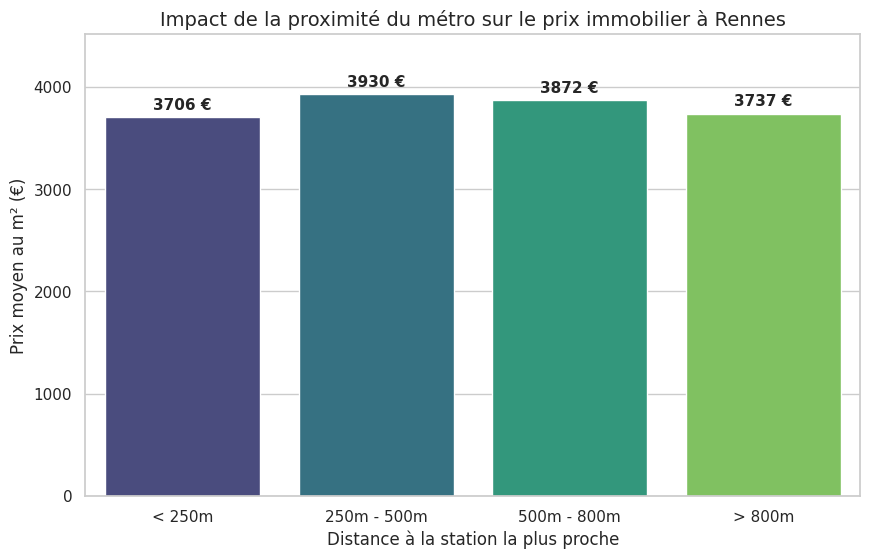


--- Statistique par variable de contrôle ---
proximite    Loin (>500m)  Proche (<500m)  Plus-value (%)
type_local                                               
Appartement   3669.264421     3755.855962        2.359916
Maison        4371.767061     4788.620027        9.535114


In [36]:
import src.stats_desc as sd

# Statistiques générales
print("--- Statistiques Globales ---")
print(sd.get_general_stats(gdf_final))

# Comparaison Ligne A vs Ligne B
print("\n--- Comparaison par Ligne de Métro ---")
stats_lignes = sd.get_stats_by_ligne(gdf_final)
print(stats_lignes)

# Statistique par tranche (distance min au métro <250, 250-500, 500-800, >800)
print("\n--- Statistique par tranche ---")
stats_tranches = sd.analyse_prix_dist_tranche(gdf_final)
print(stats_tranches)


#Graphique baton des statistiques par tranche
sd.plot_prix_par_tranche(stats_tranches)

# Statistique par variable de contrôle
print("\n--- Statistique par variable de contrôle ---")
var_control_type = sd.compare_proximity_controlled(gdf_final)
print(var_control_type)


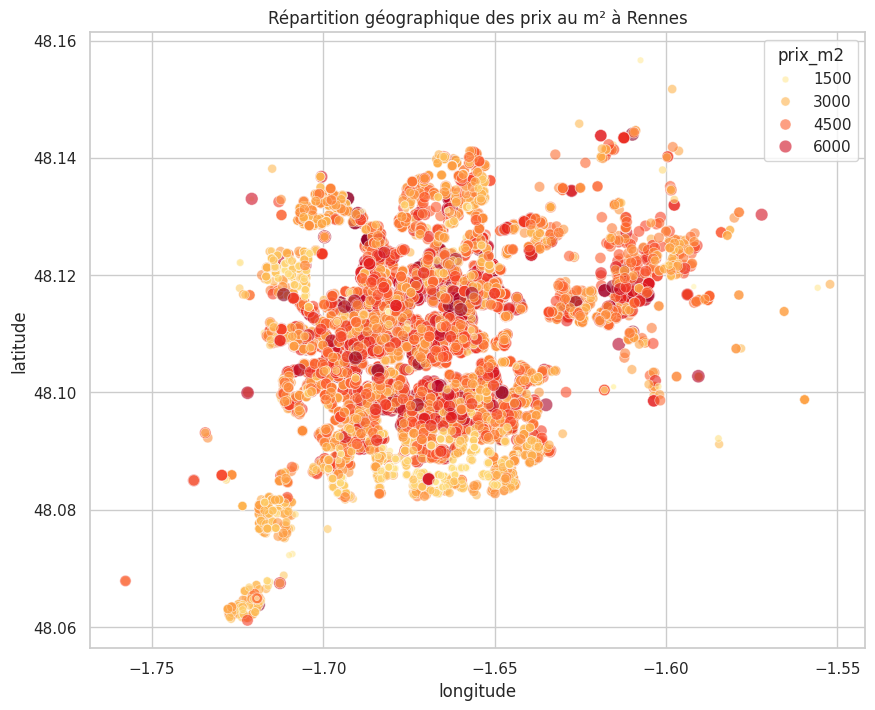

In [39]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=gdf_final, x="longitude", y="latitude", hue="prix_m2", 
                palette="YlOrRd", size="prix_m2", sizes=(10, 100), alpha=0.6)
plt.title("Répartition géographique des prix au m² à Rennes")
plt.show()

In [ ]:
sns.regplot(data=gdf_final[gdf_final['prix_m2'] < 10000], 
            x="dist_min_metro", y="prix_m2", 
            scatter_kws={'alpha':0.1}, line_kws={'color':'red'})
plt.title("Relation entre prix au m² et distance au métro")
plt.xlabel("Distance au métro le plus proche (m)")
plt.show()

KeyError: 'dist_min_metro'

DiD

In [45]:
df_ready = sd.prepare_did_data(gdf_final)
results = sd.run_did_regression(df_ready)
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                prix_m2   R-squared:                       0.155
Model:                            OLS   Adj. R-squared:                  0.154
Method:                 Least Squares   F-statistic:                     700.6
Date:                Sat, 18 Apr 2026   Prob (F-statistic):               0.00
Time:                        01:37:13   Log-Likelihood:            -1.6063e+05
No. Observations:               19155   AIC:                         3.213e+05
Df Residuals:                   19149   BIC:                         3.213e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [42]:
df_ready[['treated', 'post_event']].value_counts()

treated  post_event
0        1             9314
         0             6192
1        1             2226
         0             1423
Name: count, dtype: int64

In [ ]:
# plot_did_trends(df_ready)

## Modèle de prédiction du prix 

In [ ]:
from src.model import preparer_et_entrainer_did, predire_impact_nouvelle_station

# Bien témoin 
bien_temoin = {
    'nombre_pieces_principales': 3, 'surface_reelle_bati': 70, 'surface_terrain': 0,
    'dist_metro_A': 5000, 'dist_metro_B': 5000, 
    'annee': 2026, 'type_local': 'Appartement'
}

# Bien traité 
bien_traite = bien_temoin.copy()
bien_traite.update({'dist_metro_A': 100}) 

# Calcul de l'écart
prix_temoin = predire_impact_nouvelle_station(model_did, bien_temoin, le)
prix_traite = predire_impact_nouvelle_station(model_did, bien_traite, le)

plus_value = prix_traite - prix_temoin
print(f"La plus-value estimée du métro A est de : {plus_value:.2f} €/m²")

Calcul des distances (cela peut prendre un instant)...


/opt/python/lib/python3.13/site-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


Modèle entraîné avec succès !
Features utilisées : ['surface_reelle_bati', 'nombre_pieces_principales', 'dist_min_metro', 'annee', 'type_local_code']


In [44]:

from src.model import preparer_et_entrainer, predire_impact_nouvelle_station

# Exemple : un appartement de 50m², 3 pièces, en 2026
surface = 50
pieces = 3
annee = 2026
code_type = 1 # Supposons que 1 soit l'appartement

# Scénario 1 : Le métro est à 2 km (2000m)
prix_actuel = predire_impact_nouvelle_station(model_final, surface, pieces, code_type, annee, distance_metro=2000)

# Scénario 2 : Le métro est à 0 m (nouvelle station en bas de l'immeuble)
prix_avec_metro = predire_impact_nouvelle_station(model_final, surface, pieces, code_type, annee, distance_metro=0)

print(f"Prix estimé actuel : {prix_actuel:.2f} €")
print(f"Prix estimé avec nouvelle station : {prix_avec_metro:.2f} €")
print(f"Plus-value théorique : {prix_avec_metro - prix_actuel:.2f} €")

Prix estimé actuel : 266335.98 €
Prix estimé avec nouvelle station : 466005.00 €
Plus-value théorique : 199669.02 €
